In [1]:
import torch as tc
import numpy as np
import qutip as qt
import function as my
import mixfunn as mf
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
O_op =[ qt.sigmax(),
         qt.sigmay(),
         qt.sigmaz()
                ]


def Field(t):
    return ( 1.5* np.sin(2.0 * t) - 0.3*np.cos(3* t - 0.5) + 0.4*np.sin(7.0 * t)
        )*np.sin(np.pi*t/tfinal)**2


def data_qubit(O_op,tlist,field,device="cpu"):
    # Lista de tempos para a evolução
    H0 = 0.5*qt.sigmaz()
    H1 = 0.5*qt.sigmax()
    H  = [H0,[H1,field(tlist)]]
    
    # Hamiltonian Lindbladian
    c_ops = []
    
    # Estado inicial (cada qubit na superposição de |0> e |1>)
    # |+> = (|0> + |1>)/sqrt(2)
    theta1  = np.pi/4
    phi1    = 0.0 #np.pi/3
    ket_plus1 = (np.cos(theta1)*qt.basis(2, 0)+np.sin(theta1)*np.exp(1j*phi1)*qt.basis(2, 1))
    psi0 = ket_plus1
    
    # Solução da equação de Schrödinger
    options = qt.Options(nsteps = 100000, atol = 1e-14, rtol = 1e-14)
    result  = qt.mesolve(H, psi0, tlist, c_ops=c_ops, e_ops=O_op,options=options)

    expect  = tc.tensor( np.array( result.expect),device = device).transpose(0, 1)
    return expect


/home/gubio/anaconda3/lib/python3.13/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


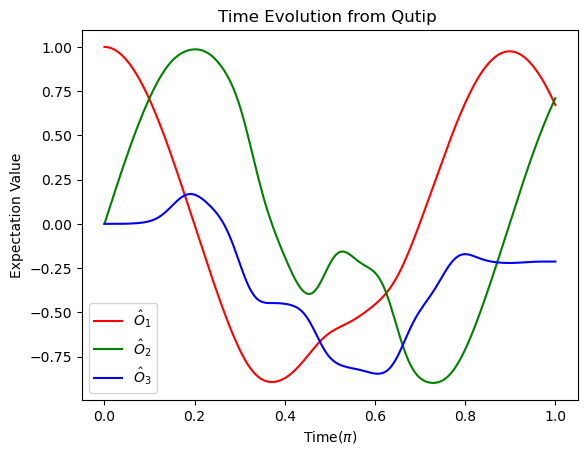

In [3]:
tfinal      = 2.52*np.pi
N           = 200
Nedo        = 3

tlist = np.linspace(0.0, tfinal, N)
valor_esperado_data  = data_qubit(O_op,tlist,Field,device="cpu")

colors = ['r', 'g', 'b']
for i in range(len(O_op)):
    plt.plot(tlist/tfinal,
             valor_esperado_data[:,i].cpu() ,
             label=fr"$\hat{{O}}_{{{i+1}}}$",
             color=colors[i])
    
plt.xlabel(r'Time($\pi$)')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('Time Evolution from Qutip ')
plt.show()

In [4]:
time = tc.linspace(
    0, tfinal, N,
    dtype = tc.float32,
    requires_grad = True).reshape((-1, 1))

X_vector = my.Rede(
    neuronio   = [15,15],
    input_     = 1,
    output_    = 3,
    activation =[mf.SIN(), mf.SIN()])

mixfunn_field = mf.MixFunn(
    N_layers = 2,
    N_neuro = 4,
    second_order_function = True)

opt = tc.optim.Adam(list(mixfunn_field.parameters())+list(X_vector.parameters()), lr=0.01, betas=(0.9,0.9))

JZ = 1e0
JY = 0e0
epocas  = 20000

100%|██████████| 20000/20000 [04:04<00:00, 81.82it/s] 


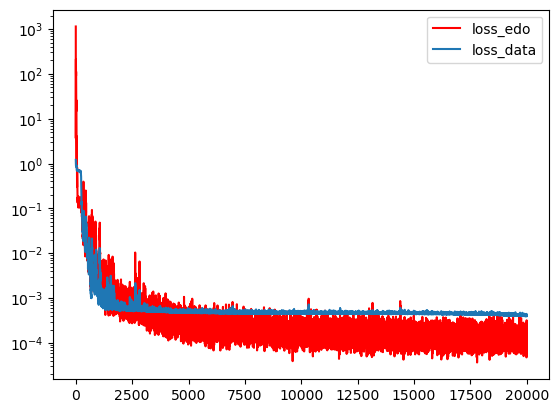

In [5]:
LOSS    = []
LOSS1   = []
LOSS2   = []
hisorty_of_param = []
for _ in tqdm(range(epocas)):
    ####### Forward pass #######
    y   = X_vector(time)    # [N,3]
    JX  = mixfunn_field(time)   # [N,1]

    ######## Loss edo #######
    dX_dt = []
    for i in range(y.shape[1]):
        dX_dt.append(
            tc.autograd.grad(
                outputs = y[:, i],
                inputs = time,
                grad_outputs = tc.ones_like(y[:, i]),
                #retain_graph = True,
                create_graph = True)[0])
    dX_dt   = tc.cat(dX_dt, dim=1)
    
    X,Y,Z = y[:, 0:1], y[:, 1:2], y[:, 2:3]
    LOSS_edo  = 0
    
    LOSS_edo += (dX_dt[:,0:1] - (-1.0*Y))**2
    LOSS_edo += (dX_dt[:,1:2] - ( 1.0*X - 1.0*JX*Z))**2
    LOSS_edo += (dX_dt[:,2:3] - ( 1.0*JX*Y))**2
    LOSS_edo = LOSS_edo.mean()


    ####### loss data(expected values) #######
    LOSS_data=0    
    LOSS_data +=(y[:,0:1]  - valor_esperado_data[:,0:1])**2 
    LOSS_data +=(y[:,1:2]  - valor_esperado_data[:,1:2])**2 
    LOSS_data +=(y[:,2:3]  - valor_esperado_data[:,2:3])**2 
    LOSS_data = LOSS_data.mean()
    

    ####### Loss total #######
    loss_i = LOSS_edo + LOSS_data + (JX[0,0] - Field(0.0))**2 + (JX[-1,0] - Field(tfinal))**2


    ####### Backpropagation #######
    opt.zero_grad()
    loss_i.backward()
    opt.step()
    LOSS1.append(LOSS_edo.cpu().detach().numpy())
    LOSS2.append(LOSS_data.cpu().detach().numpy())
    LOSS.append(loss_i.cpu().detach().numpy())

#plt.plot(LOSS,"k.",label="loss_total")
plt.plot(LOSS1,'r-',label="loss_edo")
plt.plot(LOSS2,label="loss_data")
plt.yscale("log")
plt.legend()
plt.show()

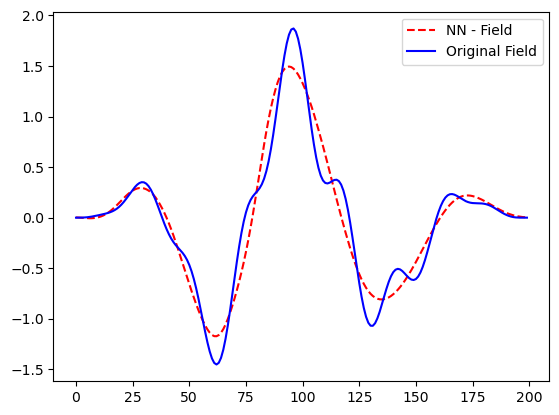

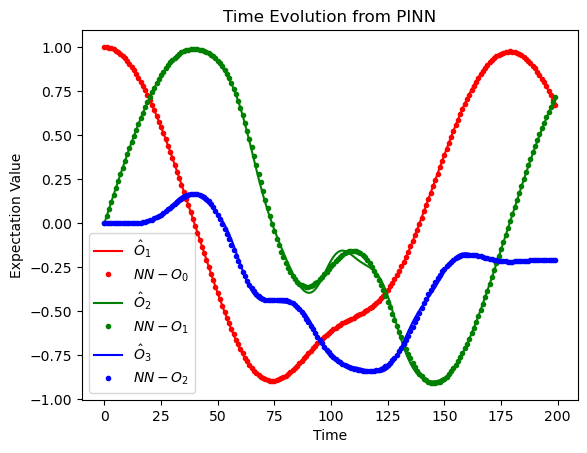

In [6]:
t_points = np.linspace(0,tfinal, N)
JX =  mixfunn_field(time).detach().numpy()

field_original=Field(t_points)
plt.plot(JX,"r--",label="NN - Field")
plt.plot(field_original,"b-",label="Original Field")
plt.legend()
plt.show()

X_vector.eval()
X_  = X_vector(time).detach().numpy()

colors = ['r', 'g', 'b']
for i in range(len(O_op)):
    plt.plot(valor_esperado_data[:,i].cpu() ,label=fr"$\hat{{O}}_{{{i+1}}}$", color=colors[i])
    plt.plot(X_[:,i],"." ,label=fr"$NN - O_{{{i}}}$", color=colors[i])
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('Time Evolution from PINN')
plt.show()


/home/gubio/anaconda3/lib/python3.13/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


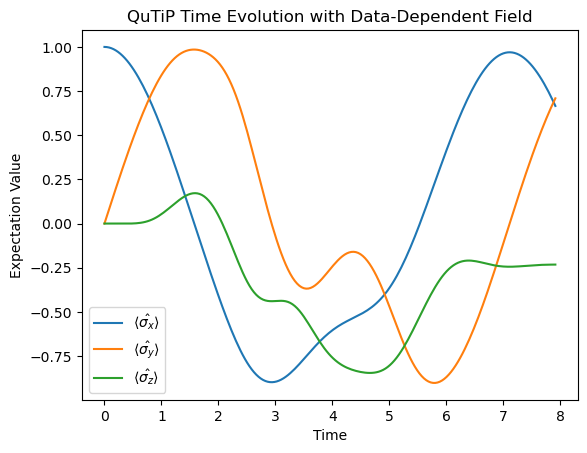

In [7]:
H0 = .5*qt.sigmaz()
H1 = .5*qt.sigmax()
# The full Hamiltonian is defined as a list: 
# H = H0 + f(t) * H1, where f(t) is the field data
H = [H0, [H1, JX.flatten()]] # QuTiP uses cubic spline interpolation for field_data

# (Optional) Define collapse operators for an open system simulation
c_ops = [] # e.g., c_ops = [np.sqrt(gamma) * qt.sigmam()]

# 3. Define the initial state and expectation value operators
theta1  = np.pi/4
phi1    = 0.0 #np.pi/3
psi0    = (np.cos(theta1)*qt.basis(2, 0)+np.sin(theta1)*np.exp(1j*phi1)*qt.basis(2, 1))

O_op =[ qt.sigmax(),
         qt.sigmay(),
         qt.sigmaz()
                ]

# 4. Simulate the time evolution
options = qt.Options(nsteps = 100000, atol = 1e-14, rtol = 1e-14)
result  = qt.mesolve(H, psi0, t_points, c_ops=c_ops, e_ops=O_op,options=options)

# 5. Plot the results
plt.figure()
plt.plot(t_points, result.expect[0], label=r'$\langle \hat{\sigma_x}\rangle$')
plt.plot(t_points, result.expect[1], label=r'$\langle \hat{\sigma_y}\rangle$')
plt.plot(t_points, result.expect[2], label=r'$\langle \hat{\sigma_z}\rangle$')

plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('QuTiP Time Evolution with Data-Dependent Field')
plt.show()

# prunning 

In [8]:
p = mixfunn_field.layers1.p.data
L = tc.sum(tc.abs(p))
p = tc.abs(p)/L
p

tensor([[5.1201e-03, 4.7106e-03, 1.0689e-04, 6.0241e-03, 4.2580e-02, 1.2115e-02,
         3.2433e-02, 6.1601e-03, 3.0377e-02, 3.9735e-02, 2.6479e-02, 1.4582e-02,
         1.4682e-02, 3.1909e-02],
        [4.6156e-03, 9.8962e-05, 4.0573e-02, 9.8962e-05, 3.7544e-02, 3.3905e-03,
         1.8345e-02, 2.6909e-02, 6.2639e-03, 6.7572e-03, 1.9874e-02, 6.0488e-04,
         4.1881e-04, 1.0742e-02],
        [9.4395e-03, 1.2171e-02, 5.4905e-03, 6.9034e-03, 1.7565e-02, 1.3734e-02,
         1.6705e-03, 2.9920e-02, 7.8466e-03, 9.5124e-03, 4.1943e-03, 7.5746e-02,
         2.0208e-02, 1.1428e-02],
        [1.8427e-05, 2.6062e-05, 1.4132e-02, 6.7945e-05, 1.1215e-02, 1.4130e-02,
         2.5963e-02, 2.4054e-02, 3.3270e-02, 5.7872e-02, 2.8949e-02, 4.0798e-02,
         5.5188e-02, 2.5237e-02]])

In [9]:
import torch.nn.utils.prune as prune
prune.l1_unstructured(mixfunn_field.layers1.project1.linear, 'weight', amount=0.1)
prune.l1_unstructured(mixfunn_field.layers1.project1.linear, 'bias', amount=0.1)

prune.l1_unstructured(mixfunn_field.layers2.project1.linear, 'weight', amount=0.1)
prune.l1_unstructured(mixfunn_field.layers2.project1.linear, 'bias', amount=0.1)

p = mixfunn_field.layers1.p.data
L = tc.sum(tc.abs(p))
p = tc.abs(p)/L
mixfunn_field.layers1.p.data = tc.where(p < 0.01, 0.0, mixfunn_field.layers1.p.data)

p = mixfunn_field.layers1.p.data
L = tc.sum(abs(p))
p = abs(p)/L

values, indices = tc.sort(p)
mask = tc.zeros(indices.shape[1])
for k in range(indices.shape[1]):
    if k > int(0.2*indices.shape[1]):
        mask[indices[0][k]] = 1.0
mixfunn_field.layers1.p.data = mask*mixfunn_field.layers1.p.data
print(mixfunn_field.layers1.p.data)

p = mixfunn_field.layers2.p.data
L = tc.sum(tc.abs(p))
p = tc.abs(p)/L
mixfunn_field.layers2.p.data = tc.where(p < 0.01, 0.0, mixfunn_field.layers2.p.data)

p = mixfunn_field.layers2.p.data
L = tc.sum(abs(p))
p = abs(p)/L

values, indices = tc.sort(p)
mask2 = tc.zeros(indices.shape[1])
for k in range(indices.shape[1]):
    if k > int(0.2*indices.shape[1]):
        mask2[indices[0][k]] = 1.0
mixfunn_field.layers2.p.data = mask2*mixfunn_field.layers2.p.data
print(mixfunn_field.layers2.p.data)


tensor([[ 0.0000,  0.0000,  0.0000,  0.0000, -1.6267,  0.4629,  1.2391,  0.0000,
         -1.1605, -1.5180, -1.0116,  0.5571, -0.5609,  1.2191],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  1.4344,  0.0000,  0.7009, -1.0281,
          0.0000,  0.0000, -0.7593,  0.0000,  0.0000, -0.4104],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.6711, -0.5247,  0.0000, -1.1431,
          0.0000,  0.0000,  0.0000,  2.8939, -0.7720, -0.4366],
        [ 0.0000,  0.0000,  0.0000,  0.0000, -0.4285, -0.5398, -0.9919, -0.9190,
          1.2710,  2.2110,  1.1060,  1.5587, -2.1084,  0.9642]])
tensor([[ 0.0000, -0.8757, -0.7158,  0.6579,  0.0000,  0.0000, -0.5010, -0.2391,
          0.1589,  0.0000,  0.1063,  1.3921, -0.3527, -0.2129]])


100%|██████████| 30000/30000 [06:16<00:00, 79.63it/s] 


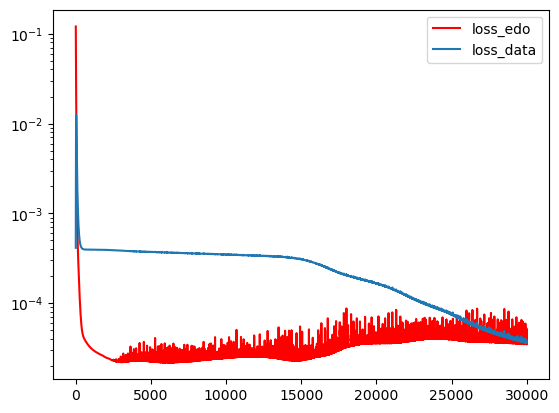

In [10]:
opt = tc.optim.Adam(
    list(mixfunn_field.parameters())+list(X_vector.parameters()),
    lr=0.001)

JZ = 1e0
JY = 0e0

epocas  = 30000

LOSS    = []
LOSS1   = []
LOSS2   = []
for _ in tqdm(range(epocas)):
    # aplicaçao da mascara para os pesos novos
    mixfunn_field.layers1.p.data = mask*mixfunn_field.layers1.p.data
    mixfunn_field.layers2.p.data = mask2*mixfunn_field.layers2.p.data

    ####### Forward pass #######
    y   = X_vector(time)    # [N,3]
    JX  = mixfunn_field(time)   # [N,1]

    ######## Loss edo #######
    dX_dt = []
    for i in range(y.shape[1]):
        dX_dt.append(
            tc.autograd.grad(
                outputs = y[:, i],
                inputs = time,
                grad_outputs = tc.ones_like(y[:, i]),
                #retain_graph = True,
                create_graph = True)[0])
    dX_dt   = tc.cat(dX_dt, dim=1)
    
    X,Y,Z = y[:, 0:1], y[:, 1:2], y[:, 2:3]
    LOSS_edo  = 0
    
    LOSS_edo += (dX_dt[:,0:1] - (-1.0*Y))**2
    LOSS_edo += (dX_dt[:,1:2] - ( 1.0*X - 1.0*JX*Z))**2
    LOSS_edo += (dX_dt[:,2:3] - ( 1.0*JX*Y))**2
    LOSS_edo = LOSS_edo.mean()


    ####### loss data(expected values) #######
    LOSS_data=0    
    LOSS_data +=(y[:,0:1]  - valor_esperado_data[:,0:1])**2 
    LOSS_data +=(y[:,1:2]  - valor_esperado_data[:,1:2])**2 
    LOSS_data +=(y[:,2:3]  - valor_esperado_data[:,2:3])**2 
    LOSS_data = LOSS_data.mean()
    

    ####### Loss total #######
    loss_i = LOSS_edo + LOSS_data + (JX[0,0] - Field(0.0))**2 + (JX[-1,0] - Field(tfinal))**2


    ####### Backpropagation #######
    opt.zero_grad()
    loss_i.backward()
    opt.step()
    LOSS1.append(LOSS_edo.cpu().detach().numpy())
    LOSS2.append(LOSS_data.cpu().detach().numpy())
    LOSS.append(loss_i.cpu().detach().numpy())

#plt.plot(LOSS,"k.",label="loss_total")
plt.plot(LOSS1,'r-',label="loss_edo")
plt.plot(LOSS2,label="loss_data")
plt.yscale("log")
plt.legend()
plt.show()

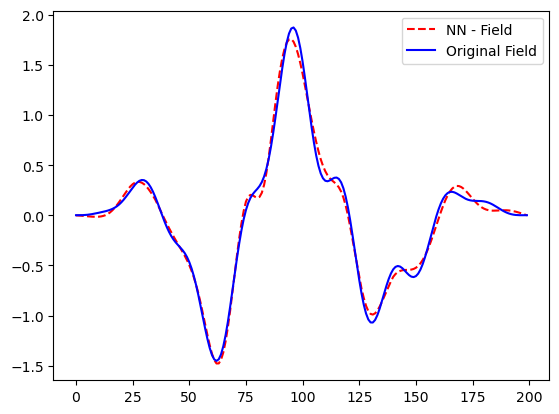

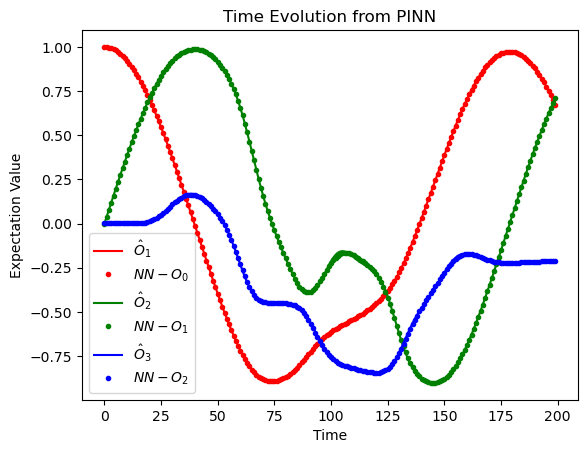

In [11]:
t_points = np.linspace(0,tfinal, N)
JX =  mixfunn_field(time).detach().numpy()

field_original=Field(t_points)
plt.plot(JX,"r--",label="NN - Field")
plt.plot(field_original,"b-",label="Original Field")
plt.legend()
plt.show()

X_vector.eval()
X_  = X_vector(time).detach().numpy()

colors = ['r', 'g', 'b']
for i in range(len(O_op)):
    plt.plot(valor_esperado_data[:,i].cpu() ,label=fr"$\hat{{O}}_{{{i+1}}}$", color=colors[i])
    plt.plot(X_[:,i],"." ,label=fr"$NN - O_{{{i}}}$", color=colors[i])
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.title('Time Evolution from PINN')
plt.show()
